In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import re
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns

Index(['Title', 'Database', 'Year', 'Month', 'Journal or Conference',
       'Paper Type', 'Data Source', 'Data Country', 'Data Domain',
       'Data Language', 'Data Availability', 'Link to Data', 'Data Details',
       'Size', 'Number of Prompts If Applicable', 'Medical Application',
       'Task Type', 'Topic', 'Note', 'Bias Evaluation Metric',
       'Bias Definition', 'Conclusions', 'Race or Ethnic Bias',
       'Language Bias', 'Age Bias', 'Gender Bias', 'Other Bias', 'LGBTQ+ Bias',
       'Disability Bias', 'Geography or Cultural Bias', 'Evaluated LLMs',
       'Reference Standard', 'Patient Inclusion', 'Has Debiasing',
       'Debias Focus', 'Debiasing Method', 'Debias Details'],
      dtype='object')

In [3]:
bias_freqs_lst = df["Language Bias"].tolist()

bias_freqs = defaultdict(int)

for s in bias_freqs_lst:
    if isinstance(s, float):
        bias_freqs[str(s)] += 1
        continue
    s = str(s).strip().lower()
    s = s.replace("_", " ")
    if s == "no":
        bias_freqs[s] += 1
        continue
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue
    items = match.group(1)
    for label in items.split(","):
        lab = label.strip()
        if lab:
            bias_freqs[lab] += 1

bias_freqs

defaultdict(int,
            {'no': 71,
             'chinese': 2,
             'english': 10,
             'arabic': 2,
             'spanish': 4,
             'non-arabic': 1,
             'aave': 1,
             'standard english': 1,
             'traditional chinese': 1,
             'simplified chinese': 1,
             'polish': 1,
             'saudi arabic': 1,
             'egyptian arabic': 1,
             'lebanese arabic': 1,
             'moroccan arabic': 1,
             'kazakh': 1,
             'russian': 1,
             'japanese': 1,
             'dutch': 1})

In [4]:
bias_freqs.pop("no", None)

bias_freqs["english"] += bias_freqs.pop("aave", 0)
bias_freqs["english"] += bias_freqs.pop("standard english", 0)

for k in ["saudi arabic", "egyptian arabic", "lebanese arabic", "moroccan arabic"]:
    bias_freqs["arabic"] += bias_freqs.pop(k, 0)

bias_freqs["chinese"] += bias_freqs.pop("traditional chinese", 0)
bias_freqs["chinese"] += bias_freqs.pop("simplified chinese", 0)

bias_freqs["portuguese"] += bias_freqs.pop("brazilian portuguese", 0)

bias_freqs

defaultdict(int,
            {'chinese': 4,
             'english': 12,
             'arabic': 6,
             'spanish': 4,
             'non-arabic': 1,
             'polish': 1,
             'kazakh': 1,
             'russian': 1,
             'japanese': 1,
             'dutch': 1,
             'portuguese': 0})

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_83900/2968130074.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")


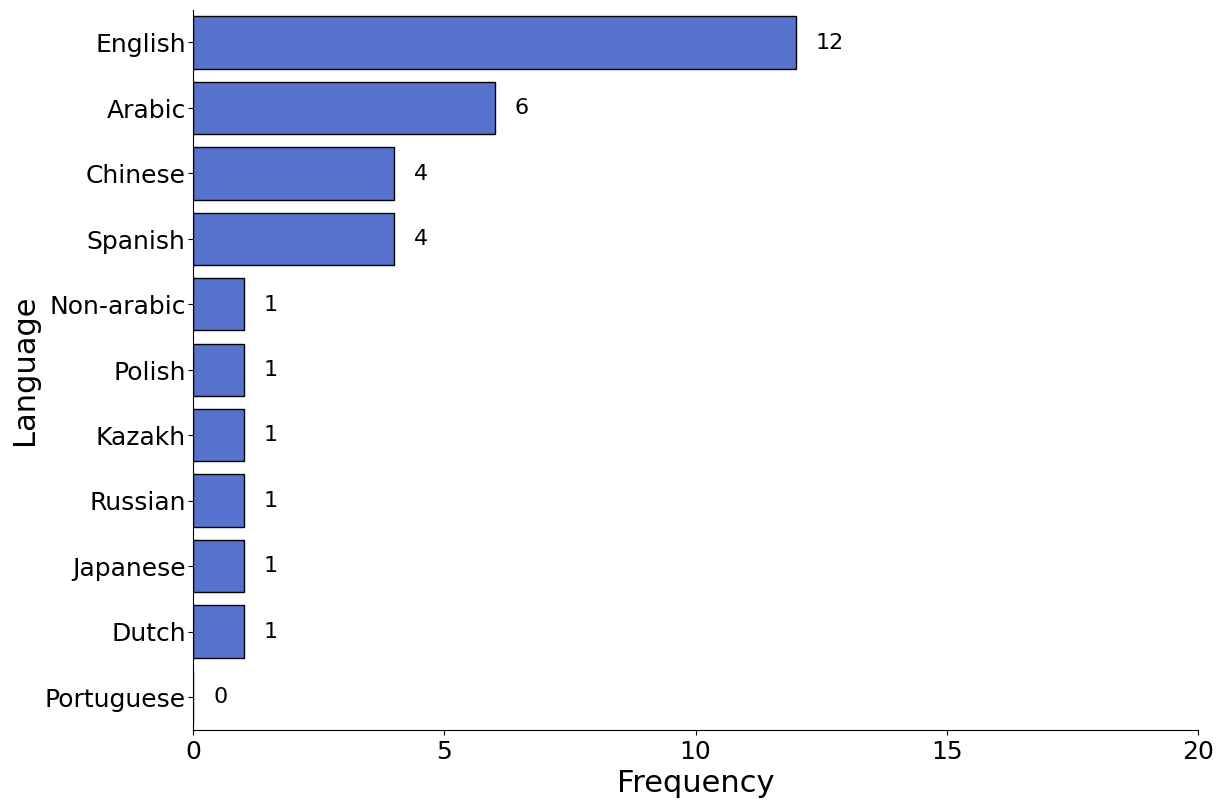

In [ ]:
def smart_title(s: str) -> str:
    return " ".join(w.capitalize() for w in s.split())

label_rotation = 0
x_tick_labelsize = 18
SHOW_AXIS_TITLES = True
axis_title_fontsize = 22
count_label_pad = 0.4
count_label_fontsize = 16
SAVE_SVG = True
svg_path = "language_bias.svg"
ylabel = "Language"
freq_var = bias_freqs

sorted_freqs = dict(sorted(freq_var.items(), key=lambda kv: kv[1], reverse=True))
groups = list(sorted_freqs.keys())
counts = list(sorted_freqs.values())
plot_df = pd.DataFrame({"group": [smart_title(g) for g in groups], "count": counts})

n_cats = len(groups)
fig, ax = plt.subplots(figsize=(12, max(8, 0.38 * n_cats)))

sns.barplot(
    data=plot_df,
    y="group",
    x="count",
    ax=ax,
    color="royalblue",
    edgecolor="black",
    linewidth=1,
    order=plot_df["group"],
)
sns.despine(ax=ax)

xmax_plot = int(math.ceil(max(counts) / 5.0)) * 5 + 5 if counts else 10
x_step = 10 if xmax_plot >= 40 else 5
x_gap = count_label_pad

for i, count in enumerate(counts):
    ax.text(count + x_gap, i, f"{count}", ha="left", va="center", fontsize=count_label_fontsize)

ax.set_xlim(0, xmax_plot)
ax.set_xticks(range(0, xmax_plot + 1, x_step))

if SHOW_AXIS_TITLES:
    ax.set_xlabel("Frequency", fontsize=axis_title_fontsize)
    ax.set_ylabel(ylabel, fontsize=axis_title_fontsize, labelpad=4)

ax.tick_params(axis="x", labelsize=x_tick_labelsize)
ax.tick_params(axis="y", labelsize=x_tick_labelsize, pad=2)
ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")

longest = max((len(str(t.get_text())) for t in ax.get_yticklabels()), default=10)
fig.subplots_adjust(
    left=min(0.38, max(0.11, 0.085 + 0.0058 * longest)),
    right=0.98,
    top=0.98,
    bottom=0.08,
)
if SAVE_SVG:
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig("language_bias.png", dpi=200, bbox_inches="tight")
plt.show()